# 01 — Exploratory Data Analysis

## Channel Affinity Prediction System

This notebook explores the customer, engagement, and channel activity data used to build a channel affinity prediction model.

The objective is to understand customer behavior across marketing channels, identify patterns in engagement, and validate the quality of the generated labels before moving into feature engineering and model development.

The analysis is organized into four sections:

1. Customer Overview
2. Channel Activity
3. Engagement Analysis
4. Label Analysis

**Project Goal**

Predict the communication channel a customer is most likely to engage with in the coming weeks or months. These predictions can be used to improve customer outreach and allocate marketing budget more effectively across channels.

**Note**

Behavioral analysis in this notebook focuses on the feature window (June–October 2023). Labels are generated from customer activity in November 2023 and are used only for target construction.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")

DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

customers = pd.read_csv(
    DATA_DIR / "customers.csv",
    parse_dates=["acquisition_date", "last_purchase_date"]
)

touchpoints = pd.read_csv(
    DATA_DIR / "marketing_touchpoints.csv",
    parse_dates=["timestamp"]
)

sessions = pd.read_csv(
    DATA_DIR / "sessions.csv",
    parse_dates=["session_start_timestamp"]
)

labels = pd.read_csv(
    PROCESSED_DIR / "labels.csv"
)

print("Customers :", customers.shape)
print("Touchpoints:", touchpoints.shape)
print("Sessions :", sessions.shape)
print("Labels :", labels.shape)

Customers : (40000, 13)
Touchpoints: (150000, 7)
Sessions : (200000, 9)
Labels : (28297, 6)


### Customer Overview
### Segment Distribution

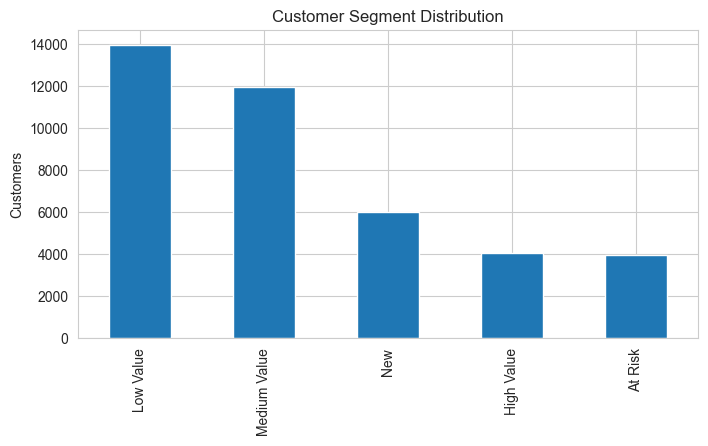

In [2]:
segment_counts = (
    customers["customer_segment"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))

segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("")
plt.ylabel("Customers")

plt.show()

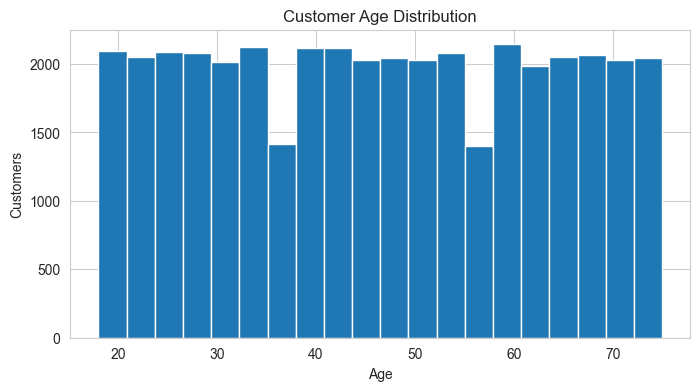

In [3]:
# Age Distribution
plt.figure(figsize=(8,4))

plt.hist(
    customers["age"],
    bins=20
)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.show()

### Channel Activity

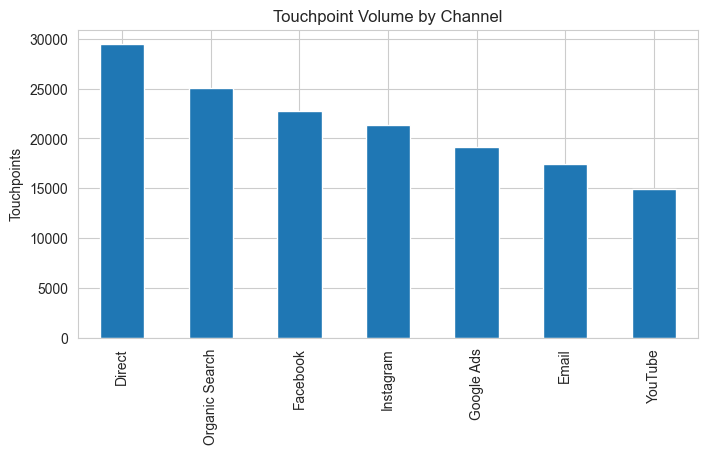

channel
Direct            29422
Organic Search    25012
Facebook          22751
Instagram         21326
Google Ads        19141
Email             17400
YouTube           14948
Name: count, dtype: int64

In [4]:
# Touchpoint Volume by Channel
channel_volume = (
    touchpoints["channel"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))

channel_volume.plot(kind="bar")

plt.title("Touchpoint Volume by Channel")
plt.xlabel("")
plt.ylabel("Touchpoints")

plt.show()

channel_volume

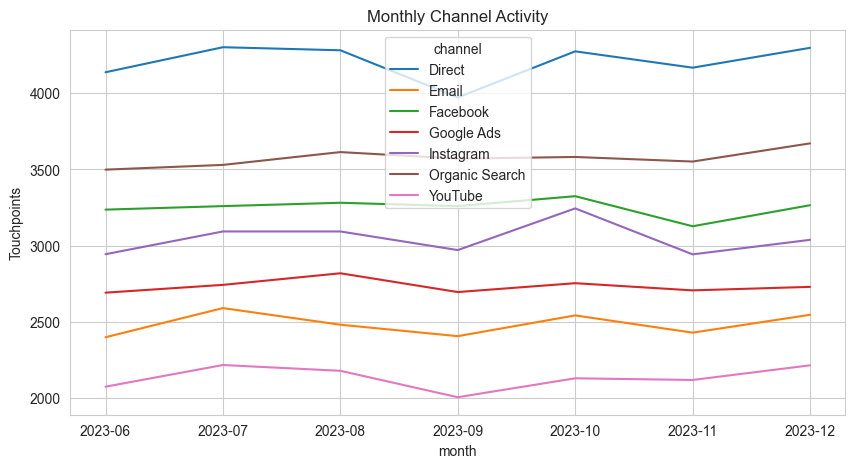

In [ ]:
# Monthly Channel Trend
monthly_tp = touchpoints.copy()

monthly_tp["month"] = (
    monthly_tp["timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_channel = (
    monthly_tp
    .groupby(["month","channel"])
    .size()
    .reset_index(name="touchpoints")
)

pivot = monthly_channel.pivot(
    index="month",
    columns="channel",
    values="touchpoints"
).fillna(0)

pivot.plot(
    figsize=(10,5)
)

plt.title("Monthly Channel Activity")
plt.ylabel("Touchpoints")

plt.show()

### Engagement Analysis

,avg_engagement,avg_duration
channel,,
YouTube,59.604056,590.174688
Email,58.602041,571.143077
Google Ads,57.561333,555.517287
Instagram,57.154428,545.331418
Facebook,57.113598,541.360198
Organic Search,56.494013,535.835039
Direct,55.871805,525.014148


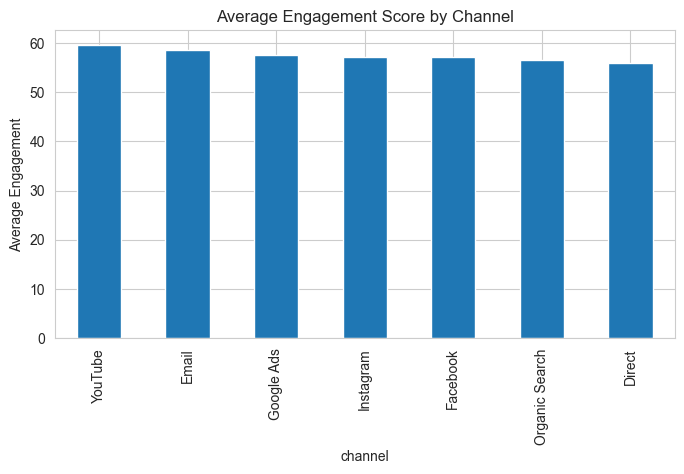

In [6]:
# Average Engagement by Channel
engagement = (
    sessions
    .groupby("channel")
    .agg(
        avg_engagement=("engagement_score","mean"),
        avg_duration=("session_duration_seconds","mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

display(engagement)

plt.figure(figsize=(8,4))

engagement["avg_engagement"].plot(kind="bar")

plt.title("Average Engagement Score by Channel")
plt.ylabel("Average Engagement")

plt.show()

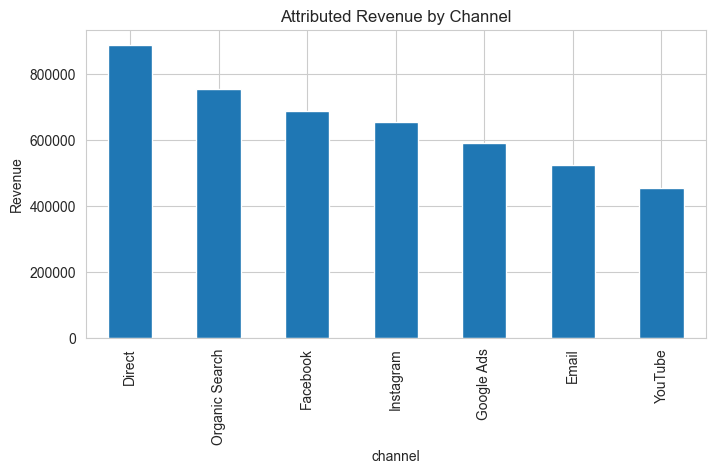

channel
Direct            887706.61
Organic Search    754970.02
Facebook          686330.58
Instagram         653585.20
Google Ads        590044.66
Email             522938.10
YouTube           455727.42
Name: revenue_attributed, dtype: float64

In [7]:
# Revenue Attribution by Channel
revenue_by_channel = (
    touchpoints
    .groupby("channel")["revenue_attributed"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))

revenue_by_channel.plot(kind="bar")

plt.title("Attributed Revenue by Channel")
plt.ylabel("Revenue")

plt.show()

revenue_by_channel

### Label Analysis

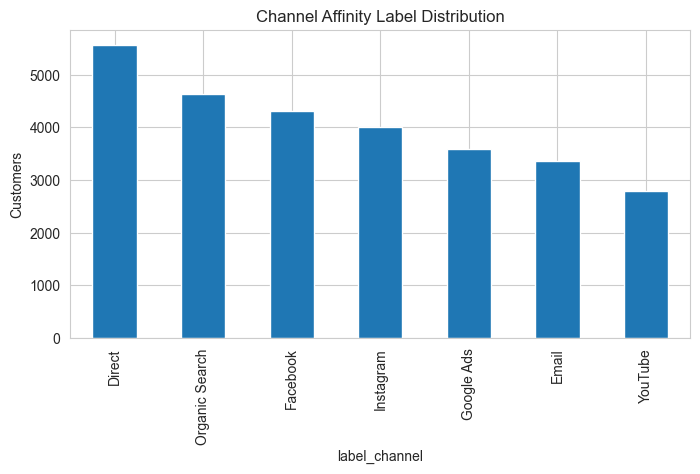

label_channel
Direct            5570
Organic Search    4644
Facebook          4316
Instagram         4017
Google Ads        3595
Email             3363
YouTube           2792
Name: count, dtype: int64

In [8]:
# Label Distribution
label_dist = (
    labels["label_channel"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))

label_dist.plot(kind="bar")

plt.title("Channel Affinity Label Distribution")
plt.ylabel("Customers")

plt.show()

label_dist

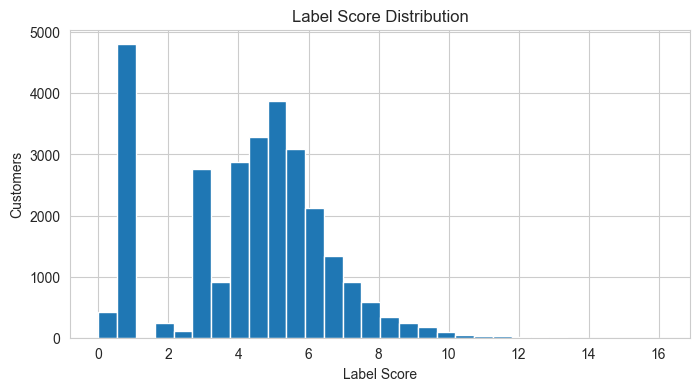

count    28297.000000
mean         4.343462
std          2.144511
min          0.000000
25%          3.000000
50%          4.641500
75%          5.681500
max         16.100250
Name: label_score, dtype: float64

In [ ]:
# Label Confidence Distribution
plt.figure(figsize=(8,4))

plt.hist(
    labels["label_score"],
    bins=30
)

plt.title("Label Score Distribution")
plt.xlabel("Label Score")
plt.ylabel("Customers")

plt.show()

labels["label_score"].describe()

In [10]:
#Confidence vs Interaction Volume
confidence_summary = (
    labels
    .groupby("low_confidence")
    ["n_interactions"]
    .agg(["count","mean","median"])
)

display(confidence_summary)

,count,mean,median
low_confidence,,,
False,24511,1.597079,1.0
True,3786,2.612784,2.0


## Key Findings

### 1. Customer Base Composition

The customer base is primarily concentrated in the **Low Value** and **Medium Value** segments, which together account for the majority of customers. High Value and At Risk customers represent smaller but strategically important groups that may require more personalized engagement strategies.

Customer ages are distributed fairly evenly between 18 and 75 years, indicating that channel preference is unlikely to be driven solely by age and will require behavioral features to capture meaningful differences.

---

### 2. Channel Activity Patterns

Customer interactions are spread across multiple channels, with **Direct** and **Organic Search** generating the highest touchpoint volumes during the feature window. Social channels such as Facebook and Instagram also contribute substantial activity, while Email and YouTube show comparatively lower interaction volumes.

Monthly channel activity remains relatively stable across the observation period, suggesting the absence of major seasonal spikes and providing a consistent behavioral signal for affinity modeling.

---

### 3. Engagement and Revenue Insights

Average engagement scores are relatively similar across channels, ranging from approximately 56 to 60. This indicates that no single channel overwhelmingly dominates customer attention and reinforces the need for a predictive approach rather than relying on simple channel popularity.

Although engagement levels are similar, channels differ significantly in scale. Direct, Organic Search, and Facebook contribute the highest attributed revenue, largely due to their higher interaction volumes. This suggests that both engagement quality and activity volume should be considered when allocating marketing budget.

---

### 4. Label Quality Assessment

The generated affinity labels are reasonably balanced across channels, with Direct and Organic Search representing the largest groups and YouTube the smallest. No channel dominates the target distribution to the extent that it would create severe class imbalance issues.

Label scores are centered around a median of approximately 4.6, indicating that most labels are supported by multiple behavioral signals rather than being assigned from a single interaction.

Only about **13% of customers** fall into the low-confidence category (3,786 out of 28,297 customers), while the majority have high-confidence labels. This suggests that the label construction process successfully identifies a dominant preferred channel for most customers while still preserving realistic ambiguity for a subset of users.

---

### 5. Implications for Channel Affinity Modeling

The dataset exhibits several characteristics that make it suitable for channel affinity prediction:

* Multiple channels have meaningful customer activity.
* Engagement patterns overlap across channels, preventing trivial prediction.
* The target distribution is reasonably balanced.
* Most labels are supported by sufficient behavioral evidence.
* A realistic subset of customers exhibits ambiguous channel preferences.

Overall, the data provides a strong foundation for building a machine learning system capable of predicting the communication channel a customer is most likely to engage with in future marketing campaigns.
